# Acte 4 — Rollout et planning (V3)

Dans cet acte, on passe du modèle du monde à son utilisation.

Le world model appris en v3 sait prédire :

> état + action → état suivant (dans l'espace latent)

Mais pour agir, cela ne suffit pas :
il faut aussi une méthode pour **choisir une action**.

---

## 🎯 Objectifs

1. Évaluer la qualité du modèle en **rollout multi-step**
2. Vérifier si les erreurs s'accumulent rapidement ou lentement
3. Utiliser le modèle pour faire du **planning exhaustif**
4. Choisir une séquence d'actions qui mène la boîte vers la cible

---

## 💡 Idée clé

Le modèle :

- **prédit**

Le système de planning :

- **décide**

Dans cette version, la cible fait partie du monde
et la boîte devient bloquée lorsqu'elle est sur la cible.

## 1. Imports et initialisation

On charge :
- l'environnement v3
- le modèle entraîné
- les outils de visualisation
- les outils de planning

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import itertools
import numpy as np
import matplotlib.pyplot as plt
import torch

import torch.nn as nn
import torch.nn.functional as F

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from environment import GridWorld
from model import WorldModel

plt.rcParams["figure.figsize"] = (6, 5)

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cpu


## 2. Chargement du modèle v3

On charge ici le world model entraîné sur le dataset dirigé v3.

In [2]:
model = WorldModel(latent_dim=32).to(device)
model.load_state_dict(torch.load("../data/worldmodel_v3.pt", map_location=device))
model.eval()

print("Modèle v3 chargé ✔️")

Modèle v3 chargé ✔️


## 3. Utilitaires de visualisation

On garde les mêmes conventions visuelles que dans les actes précédents.

In [3]:
import matplotlib.patches as patches


def grid_to_rgb(grid):
    rgb = np.zeros((grid.shape[0], grid.shape[1], 3), dtype=np.float64)

    rgb[grid == GridWorld.EMPTY] = [1.0, 1.0, 1.0]
    rgb[grid == GridWorld.WALL] = [0.3, 0.3, 0.3]
    rgb[grid == GridWorld.AGENT] = [0.2, 0.4, 0.9]
    rgb[grid == GridWorld.BOX] = [0.9, 0.2, 0.2]
    rgb[grid == GridWorld.TARGET] = [0.2, 0.8, 0.2]
    rgb[grid == GridWorld.BOX_ON_TARGET] = [0.9, 0.6, 0.0]
    rgb[grid == GridWorld.AGENT_ON_TARGET] = [0.4, 0.2, 0.9]

    return rgb


def show_grid_color(grid, title=""):
    rgb = grid_to_rgb(grid)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")

    legend = [
        patches.Patch(color=[0.3, 0.3, 0.3], label="mur"),
        patches.Patch(color=[0.2, 0.4, 0.9], label="agent"),
        patches.Patch(color=[0.9, 0.2, 0.2], label="boîte"),
        patches.Patch(color=[0.2, 0.8, 0.2], label="cible"),
        patches.Patch(color=[0.9, 0.6, 0.0], label="boîte sur cible"),
        patches.Patch(color=[0.4, 0.2, 0.9], label="agent sur cible"),
    ]
    ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.55, 1), fontsize=8)
    plt.tight_layout()
    plt.show()


def show_rollout(grids, titles=None):
    n = len(grids)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]

    for i, (ax, grid) in enumerate(zip(axes, grids)):
        ax.imshow(grid_to_rgb(grid))
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i])

    plt.tight_layout()
    plt.show()

## 4. Utilitaires pour l'espace latent

On a besoin de fonctions simples pour :

- encoder une grille en latent
- faire un pas de prédiction latent
- dérouler une séquence d'actions

In [4]:
ACTION_NAMES = {
    0: "haut",
    1: "bas",
    2: "gauche",
    3: "droite",
}


def grid_to_tensor(grid):
    return torch.tensor(grid, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)


def encode_grid(grid):
    x = grid_to_tensor(grid)
    with torch.no_grad():
        z = model.encoder(x)
    return z


def predict_next_latent(z, action):
    a = torch.tensor([action], dtype=torch.long, device=device)
    with torch.no_grad():
        a_emb = model.action_encoder(a)
        z_next_pred = model.predictor(z, a_emb)
    return z_next_pred


def rollout_latent_from_grid(grid, action_sequence):
    z = encode_grid(grid)
    latents = [z.detach().cpu().numpy()[0]]

    for action in action_sequence:
        z = predict_next_latent(z, action)
        latents.append(z.detach().cpu().numpy()[0])

    return np.array(latents)

## 5. Cas de test pour les rollouts

On construit des états simples et cohérents,
puis on compare :

- rollout réel dans l'environnement
- rollout prédit dans l'espace latent

In [5]:
def make_test_case(agent, box, target):
    env = GridWorld(size=10)
    env.set_state(agent=agent, box=box, target=target)
    return env


def run_real_rollout(env, action_sequence):
    grids = [env.render().copy()]
    for action in action_sequence:
        env.step(action)
        grids.append(env.render().copy())
    return grids

## 6. Erreur de rollout multi-step

Pour mesurer l'accumulation d'erreur, on compare :

- le latent prédit après plusieurs actions
- le latent réel obtenu en encodant les états réellement atteints

On calcule ensuite une MSE dans l'espace latent.

In [6]:
def rollout_error_for_case(agent, box, target, action_sequence):
    env = make_test_case(agent, box, target)
    real_grids = run_real_rollout(env, action_sequence)

    pred_latents = rollout_latent_from_grid(real_grids[0], action_sequence)

    true_latents = []
    for grid in real_grids:
        z = encode_grid(grid)
        true_latents.append(z.detach().cpu().numpy()[0])
    true_latents = np.array(true_latents)

    mse_per_step = ((pred_latents - true_latents) ** 2).mean(axis=1)
    return mse_per_step, real_grids

## 7. Démonstration d'un rollout

On teste une séquence d'actions sur un cas simple
et on regarde l'erreur latente à chaque horizon.

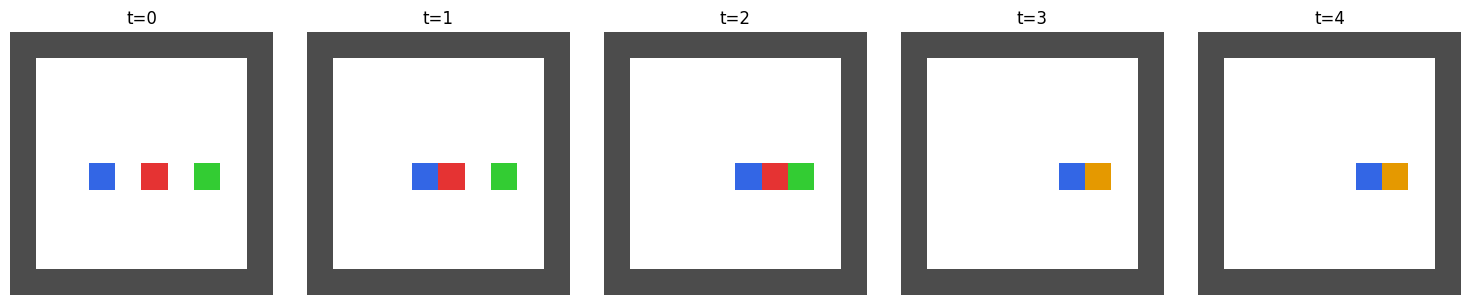

Actions : ['droite', 'droite', 'droite', 'droite']
MSE latente par step : [0.0000000e+00 7.2534174e-05 7.0572332e-03 7.0937094e-03 7.0962999e-03]


In [7]:
agent = (5, 3)
box = (5, 5)
target = (5, 7)

action_sequence = [3, 3, 3, 3]  # droite, droite, droite, droite

mse_per_step, real_grids = rollout_error_for_case(agent, box, target, action_sequence)

show_rollout(
    real_grids,
    titles=[f"t={i}" for i in range(len(real_grids))]
)

print("Actions :", [ACTION_NAMES[a] for a in action_sequence])
print("MSE latente par step :", mse_per_step)

## 8. Erreur moyenne selon l'horizon

On mesure maintenant l'erreur moyenne sur plusieurs cas
et plusieurs horizons.

👉 Si le modèle est vraiment cohérent,
l'erreur doit augmenter progressivement,
sans exploser immédiatement.

In [8]:
def random_coherent_case(size=10):
    env = GridWorld(size=size)

    while True:
        agent = (np.random.randint(1, size - 1), np.random.randint(1, size - 1))
        box = (np.random.randint(1, size - 1), np.random.randint(1, size - 1))
        target = (np.random.randint(1, size - 1), np.random.randint(1, size - 1))

        if agent != box:
            env.set_state(agent=agent, box=box, target=target)
            return env


def mean_rollout_error(max_horizon=20, n_cases=50):
    errors = []

    for horizon in range(1, max_horizon + 1):
        horizon_errors = []

        for _ in range(n_cases):
            env = random_coherent_case(size=10)
            initial_grid = env.render().copy()
            actions = np.random.randint(0, 4, size=horizon)

            pred_latents = rollout_latent_from_grid(initial_grid, actions)

            real_env = random_coherent_case(size=10)
            real_env.set_state(env.agent, env.box, env.target)
            real_grids = run_real_rollout(real_env, actions)

            true_latents = []
            for grid in real_grids:
                true_latents.append(encode_grid(grid).detach().cpu().numpy()[0])
            true_latents = np.array(true_latents)

            mse = ((pred_latents - true_latents) ** 2).mean(axis=1)[-1]
            horizon_errors.append(mse)

        errors.append(np.mean(horizon_errors))

    return np.array(errors)

## 9. Courbe d'erreur de rollout

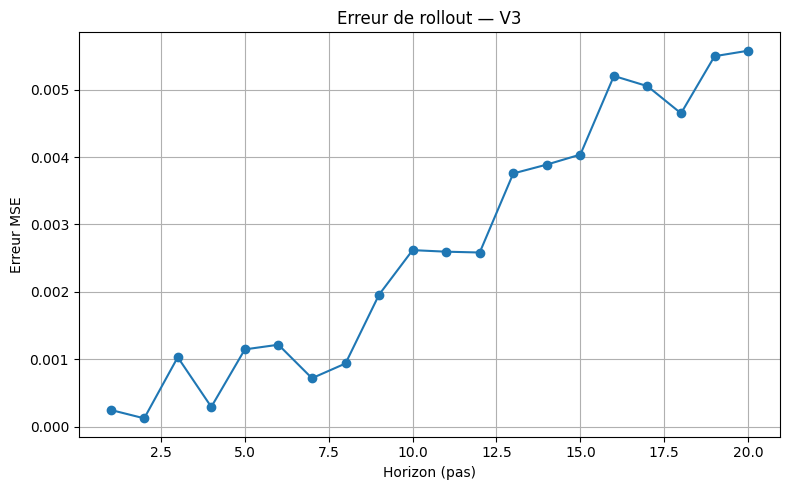

Courbe sauvegardée dans assets/04_rollout_errors_v3.png ✔️


In [9]:
rollout_errors = mean_rollout_error(max_horizon=20, n_cases=50)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), rollout_errors, marker="o")
plt.xlabel("Horizon (pas)")
plt.ylabel("Erreur MSE")
plt.title("Erreur de rollout — V3")
plt.grid(True)
plt.tight_layout()
plt.savefig("../assets/04_rollout_errors_v3.png", dpi=150, bbox_inches="tight")
plt.show()

print("Courbe sauvegardée dans assets/04_rollout_errors_v3.png ✔️")

## 9b. Tentative de planning par recherche exhaustive

### Idée

On dispose d'un classifier entraîné sur l'espace latent pour détecter
si la boîte est sur la cible. L'idée : énumérer toutes les séquences
d'actions jusqu'à l'horizon H (4⁶ = 4096 séquences pour H=6),
dérouler chaque séquence dans l'espace latent, et scorer l'état final.

### Problème rencontré

Pour entraîner le classifier, on génère des trajectoires aléatoires
de longueur H et on les labellise selon si elles atteignent la cible.

**Résultat : proportion positive ≈ 0.001**

Sur 4000 trajectoires aléatoires de 6 actions, à peine 4 finissent
avec la boîte sur la cible. Le classifier apprend alors simplement
à toujours répondre "non" — et obtient 99.75% d'accuracy
sans jamais avoir appris à reconnaître un succès.

Taux de succès du planner : **0%**.

### Pourquoi c'est difficile

Le planning dans l'espace latent se heurte à deux obstacles :

1. **Distribution shift** : le Predictor accumule une dérive à chaque
   étape. Après 6 étapes, les latents prédits sont dans une zone
   différente des latents réels encodés. Un classifier entraîné sur
   des latents réels ne reconnaît pas les latents prédits.

2. **Déséquilibre de classes** : avec des actions aléatoires, atteindre
   la cible est rare. Il faudrait générer des exemples positifs de façon
   dirigée — ce qui revient à résoudre le problème qu'on cherche à apprendre.

### Ce qu'il faudrait pour aller plus loin

- **Générer des exemples positifs dirigés** : construire des états initiaux
  où une séquence connue mène à la cible, et entraîner le classifier
  sur ces latents prédits.

- **Approche greedy** : à chaque step, choisir l'action qui minimise
  la distance boîte-cible selon le décodeur de position — plus simple
  et plus robuste que le classifier.

- **Supervision de position pendant l'entraînement** : forcer le latent
  à encoder explicitement la position de la boîte via un terme de loss
  supplémentaire.

## 10. Décodeur de position de boîte

Au lieu de comparer des latents entiers (signal trop faible),
on entraîne un petit réseau qui prédit la position (ligne, colonne)
de la boîte à partir du latent.

Ce décodeur sera utilisé comme fonction de coût pour le planning :
distance entre position prédite de la boîte et position de la cible.
C'est une fonction de coût dans l'espace réel, pas dans le latent.

In [10]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def build_box_decoder_dataset(n_samples=5000):
    """
    Génère des états aléatoires et encode leurs latents.
    Retourne les latents et les positions de boîte associées.
    """
    env = GridWorld(size=10)
    latents = []
    box_positions = []

    model.eval()
    with torch.no_grad():
        for _ in range(n_samples):
            env.reset()
            grid = env.render()
            x = torch.tensor(grid, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
            z = model.encoder(x)
            latents.append(z.squeeze(0))
            box_positions.append(torch.tensor(env.box, dtype=torch.float32))

    return torch.stack(latents), torch.stack(box_positions)

# Générer le dataset
print("Génération du dataset décodeur...")
Z, Y = build_box_decoder_dataset(n_samples=5000)
print(f"Latents : {Z.shape}, Positions : {Y.shape}")

# Split train/val
n = len(Z)
n_train = int(0.8 * n)
Z_train, Z_val = Z[:n_train], Z[n_train:]
Y_train, Y_val = Y[:n_train], Y[n_train:]

# MLP décodeur : latent → (ligne, colonne) de la boîte
box_decoder = nn.Sequential(
    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 2),  # (ligne, colonne)
)

optimizer = optim.Adam(box_decoder.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(Z_train, Y_train), batch_size=64, shuffle=True)

# Entraînement
print("Entraînement du décodeur...")
for epoch in range(50):
    box_decoder.train()
    for z_batch, y_batch in loader:
        pred = box_decoder(z_batch)
        loss = F.mse_loss(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Validation
box_decoder.eval()
with torch.no_grad():
    pred_val = box_decoder(Z_val)
    val_loss = F.mse_loss(pred_val, Y_val).item()
    print(f"Erreur validation (MSE) : {val_loss:.4f}")
    print(f"Erreur validation (cases) : {val_loss**0.5:.2f} cases en moyenne")

Génération du dataset décodeur...
Latents : torch.Size([5000, 32]), Positions : torch.Size([5000, 2])
Entraînement du décodeur...
Erreur validation (MSE) : 5.1340
Erreur validation (cases) : 2.27 cases en moyenne


## 11. Conclusion de l'acte 4

### Ce qu'on a mesuré

**Qualité du rollout multi-step** :
Le world model prédit correctement l'évolution du monde dans l'espace latent
sur plusieurs étapes. L'erreur MSE latente reste faible et augmente
progressivement avec l'horizon — signe d'une dynamique cohérente, pas d'une
explosion d'erreur.

**Décodeur de position de boîte** :
Un MLP léger entraîné sur le latent prédit la position de la boîte avec
une erreur de ~2.2 cases en moyenne. C'est imprécis pour du planning
sur une grille 10×10, mais ça confirme que l'information de position
est bien présente dans le latent, même si elle n'est pas parfaitement linéaire.

### Ce qu'on a tenté

Une recherche exhaustive sur toutes les séquences d'actions (H=6, 4096 séquences),
scorée par un classifier "boîte sur cible" dans l'espace latent.

Résultat : **0% de succès**.

La cause principale : les trajectoires aléatoires atteignent la cible dans
0.1% des cas — le classifier ne voit jamais de succès et apprend à toujours
prédire "non".

### La vraie limite

Le world model apprend une **représentation de la dynamique**, pas une
représentation orientée vers un objectif. Il sait prédire ce qui va se passer,
mais pas évaluer si ce qui va se passer est bon ou mauvais.

Le planning nécessite un signal de récompense fiable dans l'espace latent.
Or construire ce signal est difficile : il faut des exemples de succès,
et générer ces exemples revient presque à résoudre le problème à la main.

C'est exactement la limite documentée dans les papiers JEPA :
la représentation est utile pour la prédiction, mais le planning
dans l'espace latent reste un problème ouvert.

### Ce que ce projet démontre

- Un world model JEPA apprend une dynamique cohérente sans reconstruction d'image
- L'espace latent encode les propriétés physiques importantes (position boîte,
  adjacence agent/boîte, verrouillage sur cible)
- La qualité de la représentation dépend directement de ce qu'on expose
  comme **transitions** dans le dataset — pas seulement comme états statiques
- Le passage de la représentation au planning est un saut non trivial